# 02 Yelp Restaurant EDA and Feature Engineering

This notebook explores the cleaned U.S.-based Yelp restaurant business dataset and prepares business-level features for the restaurant risk and opportunity model.

The main goal is to understand restaurant patterns across ratings, review volume, geography, and business attributes, then create engineered features that can support later review filtering, sentiment analysis, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
business_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurants.csv"

business_df = pd.read_csv(business_path)

business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107.0,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeating': 'False', 'BusinessAcceptsCreditCards': 'False', 'BusinessParking': ""{'garage': False, 'street':...","Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', 'Wednesday': '7:0-20:0', 'Thursday': '7:0-20:0', 'Friday': '7:0-21:0', 'Saturday': '7:0-21:0', 'Sund..."
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015.0,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCreditCards': 'True', 'RestaurantsAttire': ""u'casual'"", 'OutdoorSeating': 'True', 'RestaurantsReservat...","Burgers, Fast Food, Sandwiches, Food, Ice Cream & Frozen Yogurt, Restaurants","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', 'Wednesday': '6:0-22:0', 'Thursday': '6:0-22:0', 'Friday': '9:0-0:0', 'Saturday': '9:0-22:0', 'Sunday..."
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123.0,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': ""u'full_bar'"", 'RestaurantsAttire': ""u'casual'"", 'RestaurantsDelivery': 'False', 'RestaurantsTakeOut': 'True', 'HasT...","Pubs, Restaurants, Italian, Bars, American (Traditional), Nightlife, Greek",NaN
3,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207.0,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ""'casual'"", 'RestaurantsGoodForGroups': 'False', 'BusinessAcceptsCreditCards': 'True', 'OutdoorSeating': 'True', 'GoodForKid...","Ice Cream & Frozen Yogurt, Fast Food, Burgers, Restaurants, Food","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', 'Wednesday': '6:0-21:0', 'Thursday': '6:0-16:0', 'Friday': '6:0-16:0', 'Saturday': '6:0-17:0', 'Sunda..."
4,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602.0,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ""'none'"", 'OutdoorSeating': 'None', 'RestaurantsReservations': 'False', 'Ambience': ""{'touristy': False, 'hipster': False, 'romantic':...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0', 'Wednesday': '11:0-14:0', 'Thursday': '11:0-14:0', 'Friday': '11:0-14:0', 'Saturday': '5:0-10:0', ..."


In [11]:
#inspect the shape
business_df.shape

(49857, 14)

The dataset contains U.S.-based restaurant businesses filtered from the Yelp Open Dataset. Each row represents one restaurant business.

In [12]:
#Basic data inspection
business_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49857 entries, 0 to 49856
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   49857 non-null  object 
 1   name          49857 non-null  object 
 2   address       49420 non-null  object 
 3   city          49857 non-null  object 
 4   state         49857 non-null  object 
 5   postal_code   49838 non-null  float64
 6   latitude      49857 non-null  float64
 7   longitude     49857 non-null  float64
 8   stars         49857 non-null  float64
 9   review_count  49857 non-null  int64  
 10  is_open       49857 non-null  int64  
 11  attributes    49347 non-null  object 
 12  categories    49857 non-null  object 
 13  hours         42973 non-null  object 
dtypes: float64(4), int64(2), object(8)
memory usage: 5.3+ MB


In [13]:
business_df.describe(include="all")

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
count,49857,49857,49420,49857,49857,49838.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49347,49857,42973
unique,49857,35082,39775,905,17,NaN,NaN,NaN,NaN,NaN,NaN,48030,30391,19889
top,2O2K6SXPWv56amqxCECd4w,McDonald's,51 N 12th St,Philadelphia,PA,NaN,NaN,NaN,NaN,NaN,NaN,"{'RestaurantsDelivery': 'True', 'RestaurantsTakeOut': 'True'}","Restaurants, Pizza","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'Wednesday': '0:0-0:0', 'Thursday': '0:0-0:0', 'Friday': '0:0-0:0', 'Saturday': '0:0-0:0', 'Sunday': '..."
freq,1,665,31,5852,12641,NaN,NaN,NaN,NaN,NaN,NaN,170,895,1279
mean,NaN,NaN,NaN,NaN,NaN,42462.350897,36.198336,-86.601887,3.516136,90.155364,0.666947,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,24970.152614,4.901975,12.907281,0.832226,192.830866,0.471310,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,7836.000000,27.564457,-120.083748,1.000000,5.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19147.000000,32.101558,-90.113459,3.000000,14.000000,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,34668.000000,38.747097,-82.782320,3.500000,35.000000,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,63116.000000,39.949438,-75.306335,4.000000,93.000000,1.000000,NaN,NaN,NaN


In [14]:
#check for missing values
missing_values = business_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


,0
hours,6884
attributes,510
address,437
postal_code,19


In [37]:
#fix postal code type
business_df["postal_code"] = business_df["postal_code"].astype("Int64").astype(str)
business_df["postal_code"] = business_df["postal_code"].replace("<NA>", np.nan)

In [38]:
business_df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'log_review_count', 'city_clean'],
      dtype='object')

## EDA Section


In [39]:
#Restaurant Count by State
state_counts = business_df["state"].value_counts().reset_index()
state_counts.columns = ["state", "restaurant_count"]

state_counts.head(20)

,state,restaurant_count
0,PA,12641
1,FL,8731
2,TN,4352
3,MO,4247
4,IN,4150
5,LA,3640
6,NJ,3341
7,AZ,2671
8,NV,1673
9,ID,1302


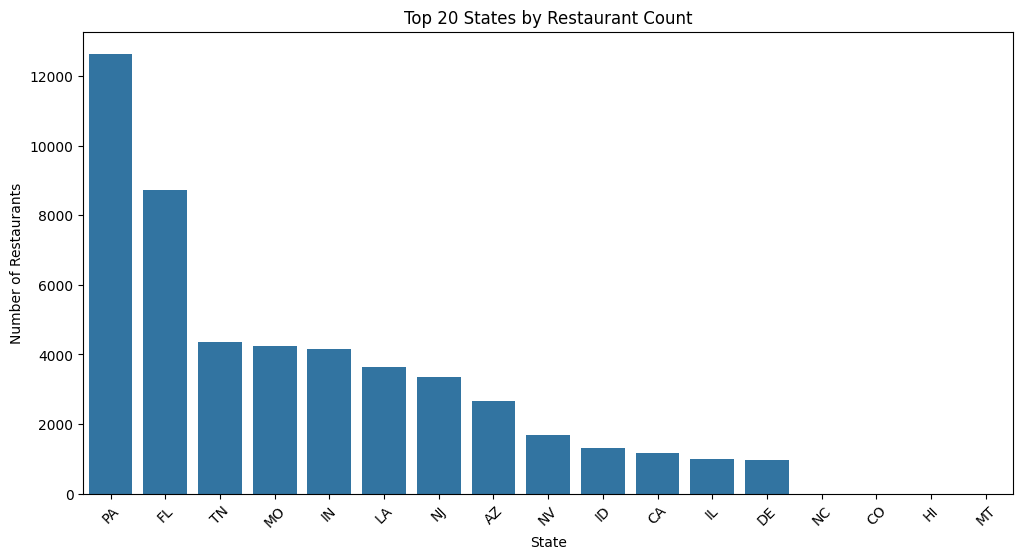

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(data=state_counts.head(20), x="state", y="restaurant_count")
plt.title("Top 20 States by Restaurant Count")
plt.xlabel("State")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

This chart shows which states have the highest number of restaurant records in the filtered Yelp dataset. This helps confirm the geographic concentration of the sample before modeling.

In [41]:
business_df["city_clean"] = business_df["city"].str.strip().str.title()

business_df["city_clean"] = business_df["city_clean"].replace({
    "St. Louis": "Saint Louis",
    "St Louis": "Saint Louis",
    "St. Petersburg": "Saint Petersburg",
    "St Petersburg": "Saint Petersburg"
})

In [42]:
#Resturant Count by City
city_counts = business_df["city_clean"].value_counts().reset_index()
city_counts.columns = ["city_clean", "restaurant_count"]

city_counts.head(20)

,city_clean,restaurant_count
0,Philadelphia,5855
1,Tampa,2967
2,Indianapolis,2863
3,Nashville,2505
4,Saint Louis,2484
5,Tucson,2469
6,New Orleans,2261
7,Reno,1288
8,Saint Petersburg,1017
9,Boise,848


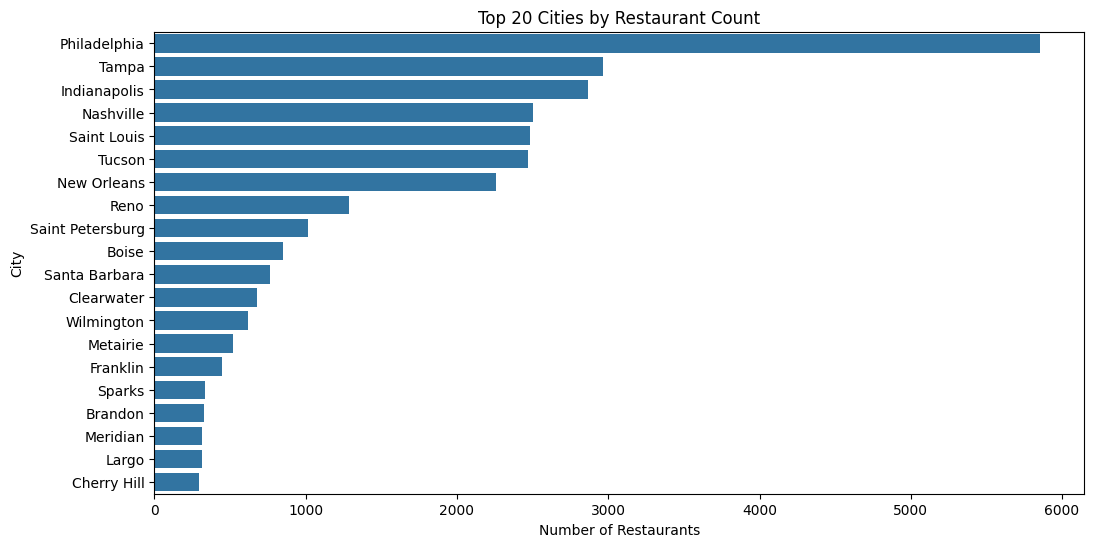

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=city_counts.head(20), x="restaurant_count", y="city_clean")
plt.title("Top 20 Cities by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

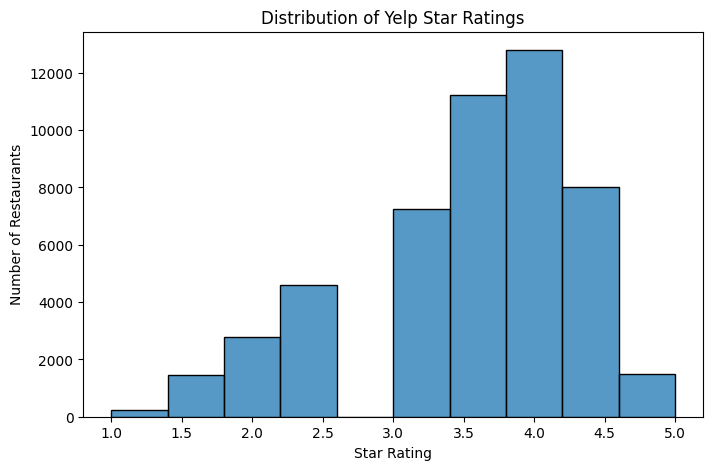

In [44]:
#rating distrubution
plt.figure(figsize=(8, 5))
sns.histplot(business_df["stars"], bins=10, kde=False)
plt.title("Distribution of Yelp Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Restaurants")
plt.show()

In [45]:
business_df["stars"].describe()

,stars
count,49857.000000
mean,3.516136
std,0.832226
min,1.000000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


The rating distribution shows how Yelp star ratings are spread across restaurants. This is important because star rating may become a key feature or possible target variable in later modeling.

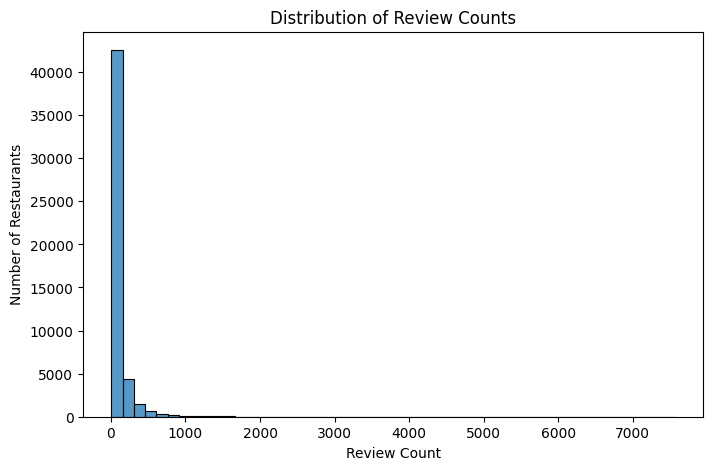

In [46]:
#review count distribution
plt.figure(figsize=(8, 5))
sns.histplot(business_df["review_count"], bins=50)
plt.title("Distribution of Review Counts")
plt.xlabel("Review Count")
plt.ylabel("Number of Restaurants")
plt.show()

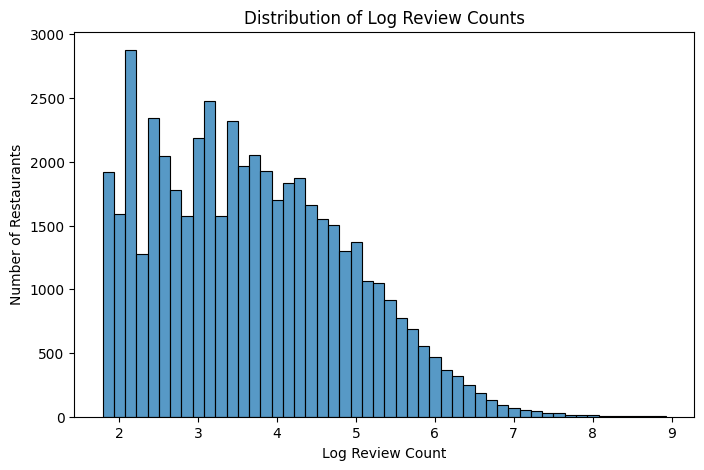

In [47]:
business_df["log_review_count"] = np.log1p(business_df["review_count"])

plt.figure(figsize=(8, 5))
sns.histplot(business_df["log_review_count"], bins=50)
plt.title("Distribution of Log Review Counts")
plt.xlabel("Log Review Count")
plt.ylabel("Number of Restaurants")
plt.show()

Review count is highly skewed because a small number of restaurants receive a very large number of reviews. A log-transformed review count helps reduce the impact of extreme values and may be more useful for modeling.

In [48]:
#open vs. closed resturants
open_counts = business_df["is_open"].value_counts().reset_index()
open_counts.columns = ["is_open", "count"]

open_counts

,is_open,count
0,1,33252
1,0,16605


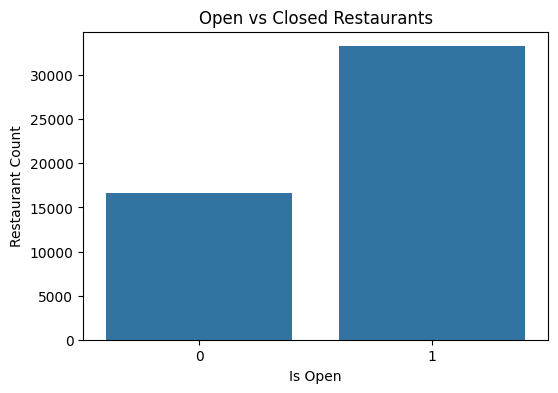

In [49]:
plt.figure(figsize=(6, 4))
sns.barplot(data=open_counts, x="is_open", y="count")
plt.title("Open vs Closed Restaurants")
plt.xlabel("Is Open")
plt.ylabel("Restaurant Count")
plt.show()

The is_open field shows whether a business is marked as open or closed in Yelp. This can be useful as a business status feature, but it should be handled carefully because the Yelp dataset may not reflect real-time business status.

In [50]:
#Average rating by state
state_rating = (
    business_df.groupby("state")
    .agg(
        avg_rating=("stars", "mean"),
        restaurant_count=("business_id", "count"),
        avg_review_count=("review_count", "mean")
    )
    .reset_index()
)

state_rating = state_rating.sort_values("restaurant_count", ascending=False)

state_rating.head(20)

,state,avg_rating,restaurant_count,avg_review_count
15,PA,3.521557,12641,83.925797
4,FL,3.578342,8731,87.485626
16,TN,3.475184,4352,97.368796
10,MO,3.445844,4247,80.355545
8,IN,3.464699,4150,78.049398
9,LA,3.595192,3640,149.714835
13,NJ,3.484136,3341,48.994912
0,AZ,3.453201,2671,95.595657
14,NV,3.537956,1673,138.695158
6,ID,3.544931,1302,74.132873


In [51]:
#optional filter to state with enough resturant count
state_rating_filtered = state_rating[state_rating["restaurant_count"] >= 100]

state_rating_filtered.sort_values("avg_rating", ascending=False).head(10)

,state,avg_rating,restaurant_count,avg_review_count
1,CA,3.762705,1161,177.624462
9,LA,3.595192,3640,149.714835
4,FL,3.578342,8731,87.485626
6,ID,3.544931,1302,74.132873
14,NV,3.537956,1673,138.695158
15,PA,3.521557,12641,83.925797
13,NJ,3.484136,3341,48.994912
16,TN,3.475184,4352,97.368796
8,IN,3.464699,4150,78.049398
0,AZ,3.453201,2671,95.595657


In [52]:
business_df["business_id"].duplicated().sum()

np.int64(0)

In [53]:
state_counts.tail(10)

,state,restaurant_count
7,AZ,2671
8,NV,1673
9,ID,1302
10,CA,1161
11,IL,983
12,DE,961
13,NC,1
14,CO,1
15,HI,1
16,MT,1


A few states have very small restaurant counts. These records will be kept in the dataset, but state-level comparisons should focus on states with a meaningful number of restaurants.

# Feature Engineering

In this section, I create business-level features from the Yelp restaurant dataset. These features are designed to support later modeling and analysis around restaurant risk, opportunity, review volume, business status, and restaurant category type.

In [54]:
#creating log review count
# Create log-transformed review count to reduce skew
business_df["log_review_count"] = np.log1p(business_df["review_count"])

business_df[["review_count", "log_review_count"]].head()

,review_count,log_review_count
0,80,4.394449
1,6,1.945910
2,19,2.995732
3,10,2.397895
4,10,2.397895


Review count is highly skewed because some restaurants receive significantly more reviews than others. The log_review_count feature reduces the impact of extreme review counts and makes the feature more useful for modeling.

In [55]:
#create rating group
def rating_group(stars):
    if stars >= 4.5:
        return "High Rated"
    elif stars >= 3.5:
        return "Average Rated"
    else:
        return "Low Rated"

business_df["rating_group"] = business_df["stars"].apply(rating_group)

business_df["rating_group"].value_counts()

,count
rating_group,
Average Rated,24008
Low Rated,16316
High Rated,9533


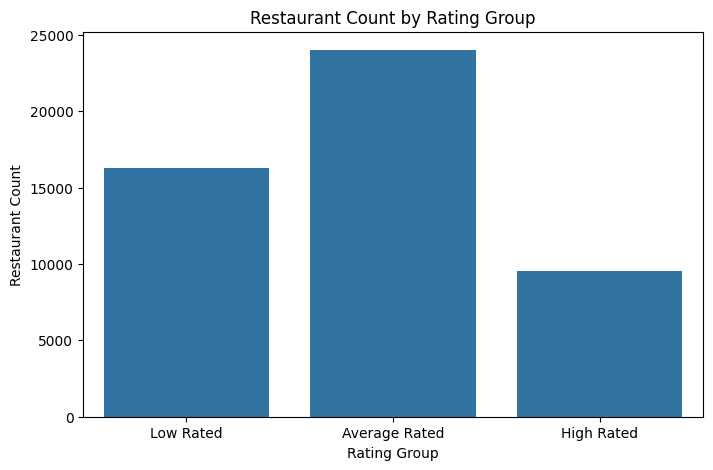

In [56]:
plt.figure(figsize=(8, 5))
sns.countplot(data=business_df, x="rating_group", order=["Low Rated", "Average Rated", "High Rated"])
plt.title("Restaurant Count by Rating Group")
plt.xlabel("Rating Group")
plt.ylabel("Restaurant Count")
plt.show()

The rating_group feature turns Yelp star ratings into business-friendly categories. This makes it easier to compare low-rated, average-rated, and high-rated restaurants.

In [57]:
#create review volume group
business_df["review_volume_group"] = pd.qcut(
    business_df["review_count"],
    q=4,
    labels=[
        "Low Review Volume",
        "Moderate Review Volume",
        "High Review Volume",
        "Very High Review Volume"
    ],
    duplicates="drop"
)

business_df["review_volume_group"].value_counts()


,count
review_volume_group,
Low Review Volume,12980
Very High Review Volume,12370
High Review Volume,12286
Moderate Review Volume,12221


The review_volume_group feature separates restaurants into four review volume groups. This is useful because a restaurant with a high rating and very few reviews may not have the same business signal as a restaurant with a high rating and many reviews.

In [58]:
#create risk related flags
# Low rating flag
business_df["low_rating_flag"] = np.where(business_df["stars"] < 3.5, 1, 0)

# Low review count flag based on median review count
median_review_count = business_df["review_count"].median()

business_df["low_review_count_flag"] = np.where(
    business_df["review_count"] < median_review_count,
    1,
    0
)

# Closed business flag
business_df["closed_flag"] = np.where(business_df["is_open"] == 0, 1, 0)

business_df[
    ["stars", "review_count", "is_open", "low_rating_flag", "low_review_count_flag", "closed_flag"]
].head()

,stars,review_count,is_open,low_rating_flag,low_review_count_flag,closed_flag
0,4.0,80,1,0,0,0
1,2.0,6,1,1,1,0
2,3.0,19,0,1,1,1
3,1.5,10,1,1,1,0
4,4.0,10,1,0,1,0


In [60]:
#check flag counts
business_df[
    ["low_rating_flag", "low_review_count_flag", "closed_flag"]
].sum()

,0
low_rating_flag,16316
low_review_count_flag,24829
closed_flag,16605


These flags identify basic restaurant risk signals: low rating, below-median review count, and closed business status. These are simple rule-based features and are not the final model outcome.

In [62]:
#create basic risk score
business_df["basic_risk_score"] = (
    business_df["low_rating_flag"] +
    business_df["low_review_count_flag"] +
    business_df["closed_flag"]
)

business_df["basic_risk_score"].value_counts().sort_index()

,count
basic_risk_score,
0,14443
1,16966
2,14560
3,3888


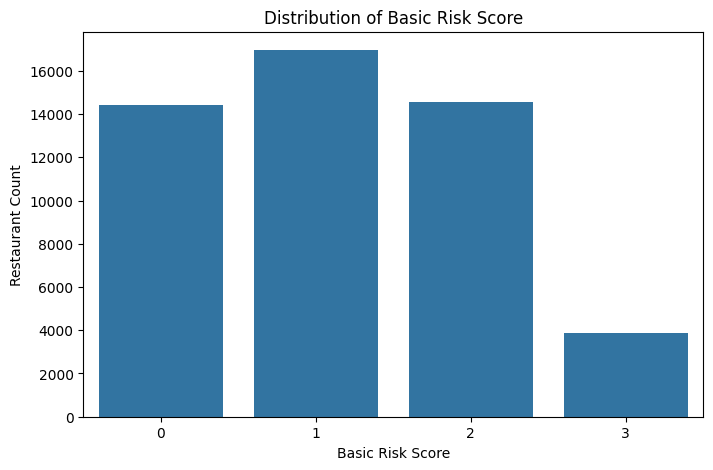

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(data=business_df, x="basic_risk_score")
plt.title("Distribution of Basic Risk Score")
plt.xlabel("Basic Risk Score")
plt.ylabel("Restaurant Count")
plt.show()

The basic_risk_score gives one point for each risk signal: low rating, low review count, and closed status. A higher score means the restaurant has more risk indicators. This is an early business rule feature that can be improved later with review sentiment.

In [64]:
#create opportunity flag
# High rating flag
business_df["high_rating_flag"] = np.where(business_df["stars"] >= 4.0, 1, 0)

# High review count flag based on 75th percentile
review_count_75th = business_df["review_count"].quantile(0.75)

business_df["high_review_count_flag"] = np.where(
    business_df["review_count"] >= review_count_75th,
    1,
    0
)

# Opportunity flag
business_df["opportunity_flag"] = np.where(
    (business_df["high_rating_flag"] == 1) &
    (business_df["high_review_count_flag"] == 1) &
    (business_df["is_open"] == 1),
    1,
    0
)

business_df[
    ["stars", "review_count", "is_open", "high_rating_flag", "high_review_count_flag", "opportunity_flag"]
].head()

,stars,review_count,is_open,high_rating_flag,high_review_count_flag,opportunity_flag
0,4.0,80,1,1,0,0
1,2.0,6,1,0,0,0
2,3.0,19,0,0,0,0
3,1.5,10,1,0,0,0
4,4.0,10,1,1,0,0


In [65]:
business_df["opportunity_flag"].value_counts()

,count
opportunity_flag,
0,43580
1,6277


The opportunity_flag identifies restaurants that are open, highly rated, and have strong review volume. These restaurants may represent stronger market performers or useful benchmark locations.

In [66]:
#create resturant category flags
business_df["categories"].head(10)

,categories
0,"Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries"
1,"Burgers, Fast Food, Sandwiches, Food, Ice Cream & Frozen Yogurt, Restaurants"
2,"Pubs, Restaurants, Italian, Bars, American (Traditional), Nightlife, Greek"
3,"Ice Cream & Frozen Yogurt, Fast Food, Burgers, Restaurants, Food"
4,"Vietnamese, Food, Restaurants, Food Trucks"
5,"American (Traditional), Restaurants, Diners, Breakfast & Brunch"
6,"Food, Delis, Italian, Bakeries, Restaurants"
7,"Sushi Bars, Restaurants, Japanese"
8,"Korean, Restaurants"
9,"Steakhouses, Asian Fusion, Restaurants"


In [67]:
business_df["is_fast_food"] = business_df["categories"].str.contains("Fast Food", case=False, na=False).astype(int)
business_df["is_breakfast_brunch"] = business_df["categories"].str.contains("Breakfast & Brunch", case=False, na=False).astype(int)
business_df["is_coffee_tea"] = business_df["categories"].str.contains("Coffee & Tea", case=False, na=False).astype(int)
business_df["is_bars"] = business_df["categories"].str.contains("Bars", case=False, na=False).astype(int)
business_df["is_pizza"] = business_df["categories"].str.contains("Pizza", case=False, na=False).astype(int)
business_df["is_mexican"] = business_df["categories"].str.contains("Mexican", case=False, na=False).astype(int)
business_df["is_chinese"] = business_df["categories"].str.contains("Chinese", case=False, na=False).astype(int)
business_df["is_american"] = business_df["categories"].str.contains("American", case=False, na=False).astype(int)

In [68]:
#check totals
category_features = [
    "is_fast_food",
    "is_breakfast_brunch",
    "is_coffee_tea",
    "is_bars",
    "is_pizza",
    "is_mexican",
    "is_chinese",
    "is_american"
]

business_df[category_features].sum().sort_values(ascending=False)

,0
is_american,12772
is_bars,10478
is_pizza,6780
is_fast_food,6151
is_breakfast_brunch,6024
is_mexican,4556
is_coffee_tea,3839
is_chinese,2968


The category flag features convert Yelp's text-based restaurant categories into structured columns. This allows the project to compare restaurant types such as fast food, breakfast, pizza, coffee, Mexican, Chinese, and American restaurants.

In [69]:
#create state resturant density feature
state_restaurant_counts = business_df["state"].value_counts().to_dict()

business_df["state_restaurant_count"] = business_df["state"].map(state_restaurant_counts)

business_df[["state", "state_restaurant_count"]].head()

,state,state_restaurant_count
0,PA,12641
1,TN,4352
2,MO,4247
3,TN,4352
4,FL,8731


The state_restaurant_count feature adds market context by showing how many restaurants are represented in each state within the Yelp dataset. This helps distinguish restaurants in larger Yelp markets from restaurants in smaller represented markets.

In [70]:
#create city resturant density feature
city_restaurant_counts = business_df["city_clean"].value_counts().to_dict()

business_df["city_restaurant_count"] = business_df["city_clean"].map(city_restaurant_counts)

business_df[["city_clean", "city_restaurant_count"]].head()

,city_clean,city_restaurant_count
0,Philadelphia,5855
1,Ashland City,24
2,Affton,18
3,Nashville,2505
4,Tampa Bay,36


The city_restaurant_count feature adds local market context by showing how many restaurants are represented in each city. This can help compare restaurants operating in larger versus smaller local markets.

In [71]:
#create rating to market average features
# State average rating
state_avg_rating = business_df.groupby("state")["stars"].mean().to_dict()
business_df["state_avg_rating"] = business_df["state"].map(state_avg_rating)

# City average rating
city_avg_rating = business_df.groupby("city_clean")["stars"].mean().to_dict()
business_df["city_avg_rating"] = business_df["city_clean"].map(city_avg_rating)

# Difference from market averages
business_df["rating_vs_state_avg"] = business_df["stars"] - business_df["state_avg_rating"]
business_df["rating_vs_city_avg"] = business_df["stars"] - business_df["city_avg_rating"]

business_df[
    ["stars", "state", "state_avg_rating", "rating_vs_state_avg", "city_clean", "city_avg_rating", "rating_vs_city_avg"]
].head()

,stars,state,state_avg_rating,rating_vs_state_avg,city_clean,city_avg_rating,rating_vs_city_avg
0,4.0,PA,3.521557,0.478443,Philadelphia,3.556277,0.443723
1,2.0,TN,3.475184,-1.475184,Ashland City,3.375000,-1.375000
2,3.0,MO,3.445844,-0.445844,Affton,3.472222,-0.472222
3,1.5,TN,3.475184,-1.975184,Nashville,3.563473,-2.063473
4,4.0,FL,3.578342,0.421658,Tampa Bay,3.861111,0.138889


The rating_vs_state_avg and rating_vs_city_avg features compare each restaurant's rating against its market average. This is useful because a 3.5-star restaurant may perform differently depending on whether its local market average is higher or lower.

In [72]:
#create review count compared to market review
# State average review count
state_avg_review_count = business_df.groupby("state")["review_count"].mean().to_dict()
business_df["state_avg_review_count"] = business_df["state"].map(state_avg_review_count)

# City average review count
city_avg_review_count = business_df.groupby("city_clean")["review_count"].mean().to_dict()
business_df["city_avg_review_count"] = business_df["city_clean"].map(city_avg_review_count)

# Difference from market averages
business_df["review_count_vs_state_avg"] = business_df["review_count"] - business_df["state_avg_review_count"]
business_df["review_count_vs_city_avg"] = business_df["review_count"] - business_df["city_avg_review_count"]

business_df[
    [
        "review_count",
        "state_avg_review_count",
        "review_count_vs_state_avg",
        "city_avg_review_count",
        "review_count_vs_city_avg"
    ]
].head()

,review_count,state_avg_review_count,review_count_vs_state_avg,city_avg_review_count,review_count_vs_city_avg
0,80,83.925797,-3.925797,113.747908,-33.747908
1,6,97.368796,-91.368796,17.291667,-11.291667
2,19,80.355545,-61.355545,37.666667,-18.666667
3,10,97.368796,-87.368796,127.184032,-117.184032
4,10,87.485626,-77.485626,34.194444,-24.194444


The review count comparison features show whether a restaurant has more or fewer reviews than the average restaurant in its state or city. This adds market context to review volume instead of only looking at raw review counts.

In [73]:
#feature summary
feature_columns = [
    "stars",
    "review_count",
    "log_review_count",
    "is_open",
    "low_rating_flag",
    "low_review_count_flag",
    "closed_flag",
    "basic_risk_score",
    "high_rating_flag",
    "high_review_count_flag",
    "opportunity_flag",
    "state_restaurant_count",
    "city_restaurant_count",
    "state_avg_rating",
    "city_avg_rating",
    "rating_vs_state_avg",
    "rating_vs_city_avg",
    "state_avg_review_count",
    "city_avg_review_count",
    "review_count_vs_state_avg",
    "review_count_vs_city_avg"
] + category_features

business_df[feature_columns].describe()

,stars,review_count,log_review_count,is_open,low_rating_flag,low_review_count_flag,closed_flag,basic_risk_score,high_rating_flag,high_review_count_flag,opportunity_flag,state_restaurant_count,city_restaurant_count,state_avg_rating,city_avg_rating,rating_vs_state_avg,rating_vs_city_avg,state_avg_review_count,city_avg_review_count,review_count_vs_state_avg,review_count_vs_city_avg,is_fast_food,is_breakfast_brunch,is_coffee_tea,is_bars,is_pizza,is_mexican,is_chinese,is_american
count,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.00000,49857.000000,49857.000000,49857.000000,49857.000000,4.985700e+04,4.985700e+04,49857.000000,49857.000000,4.985700e+04,4.985700e+04,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000
mean,3.516136,90.155364,3.687846,0.666947,0.327256,0.498004,0.333053,1.158313,0.447861,0.250496,0.12590,6608.954510,1659.119341,3.516136,3.516136,-5.579507e-17,-5.372859e-17,90.155364,90.155364,1.824207e-17,3.648413e-17,0.123373,0.120826,0.077000,0.210161,0.135989,0.091381,0.059530,0.256173
std,0.832226,192.830866,1.215214,0.471310,0.469216,0.500001,0.471310,0.931993,0.497279,0.433303,0.33174,4136.914717,1879.907691,0.069236,0.183934,8.293409e-01,8.116455e-01,27.661836,44.019236,1.908365e+02,1.877393e+02,0.328868,0.325928,0.266594,0.407427,0.342780,0.288154,0.236617,0.436523
min,1.000000,5.000000,1.791759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,2.000000,1.000000,-2.595192e+00,-2.861111e+00,6.000000,5.000000,-1.726245e+02,-2.356316e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,14.000000,2.708050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3640.000000,101.000000,3.464699,3.459770,-5.215568e-01,-5.479066e-01,80.355545,56.505155,-7.192580e+01,-7.288647e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.500000,35.000000,3.583519,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,4352.000000,767.000000,3.521557,3.556277,3.530120e-02,4.022989e-02,83.925797,88.672783,-4.448563e+01,-3.263855e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,93.000000,4.543295,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.00000,12641.000000,2505.000000,3.578342,3.597561,5.353012e-01,5.388821e-01,95.595657,113.747908,6.005088e+00,1.068057e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,5.000000,7568.000000,8.931816,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.00000,12641.000000,5855.000000,5.000000,5.000000,1.695829e+00,2.571429e+00,177.624462,1175.000000,7.418285e+03,7.361842e+03,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
# Fill missing location text fields
business_df["address"] = business_df["address"].fillna("Unknown")
business_df["postal_code"] = business_df["postal_code"].fillna("Unknown")

In [79]:
#select final business feature data set
business_features_df = business_df[
    [
        "business_id",
        "name",
        "address",
        "city",
        "city_clean",
        "state",
        "postal_code",
        "latitude",
        "longitude",
        "stars",
        "review_count",
        "log_review_count",
        "is_open",
        "categories",
        "rating_group",
        "review_volume_group",
        "low_rating_flag",
        "low_review_count_flag",
        "closed_flag",
        "basic_risk_score",
        "high_rating_flag",
        "high_review_count_flag",
        "opportunity_flag",
        "state_restaurant_count",
        "city_restaurant_count",
        "state_avg_rating",
        "city_avg_rating",
        "rating_vs_state_avg",
        "rating_vs_city_avg",
        "state_avg_review_count",
        "city_avg_review_count",
        "review_count_vs_state_avg",
        "review_count_vs_city_avg"
    ] + category_features
].copy()

business_features_df.head()

,business_id,name,address,city,city_clean,state,postal_code,latitude,longitude,stars,review_count,log_review_count,is_open,categories,rating_group,review_volume_group,low_rating_flag,low_review_count_flag,closed_flag,basic_risk_score,high_rating_flag,high_review_count_flag,opportunity_flag,state_restaurant_count,city_restaurant_count,state_avg_rating,city_avg_rating,rating_vs_state_avg,rating_vs_city_avg,state_avg_review_count,city_avg_review_count,review_count_vs_state_avg,review_count_vs_city_avg,is_fast_food,is_breakfast_brunch,is_coffee_tea,is_bars,is_pizza,is_mexican,is_chinese,is_american
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,4.394449,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries",Average Rated,High Review Volume,0,0,0,0,1,0,0,12641,5855,3.521557,3.556277,0.478443,0.443723,83.925797,113.747908,-3.925797,-33.747908,0,0,1,0,0,0,0,0
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1.945910,1,"Burgers, Fast Food, Sandwiches, Food, Ice Cream & Frozen Yogurt, Restaurants",Low Rated,Low Review Volume,1,1,0,2,0,0,0,4352,24,3.475184,3.375000,-1.475184,-1.375000,97.368796,17.291667,-91.368796,-11.291667,1,0,0,0,0,0,0,0
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,Affton,MO,63123,38.565165,-90.321087,3.0,19,2.995732,0,"Pubs, Restaurants, Italian, Bars, American (Traditional), Nightlife, Greek",Low Rated,Moderate Review Volume,1,1,1,3,0,0,0,4247,18,3.445844,3.472222,-0.445844,-0.472222,80.355545,37.666667,-61.355545,-18.666667,0,0,0,1,0,0,0,1
3,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,Nashville,TN,37207,36.208102,-86.768170,1.5,10,2.397895,1,"Ice Cream & Frozen Yogurt, Fast Food, Burgers, Restaurants, Food",Low Rated,Low Review Volume,1,1,0,2,0,0,0,4352,2505,3.475184,3.563473,-1.975184,-2.063473,97.368796,127.184032,-87.368796,-117.184032,1,0,0,0,0,0,0,0
4,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Unknown,Tampa Bay,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,2.397895,1,"Vietnamese, Food, Restaurants, Food Trucks",Average Rated,Low Review Volume,0,1,0,1,1,0,0,8731,36,3.578342,3.861111,0.421658,0.138889,87.485626,34.194444,-77.485626,-24.194444,0,0,0,0,0,0,0,0


In [80]:
business_features_df.shape

(49857, 41)

In [81]:
business_features_df.isnull().sum().sort_values(ascending=False)

,0
business_id,0
name,0
address,0
city,0
city_clean,0
state,0
postal_code,0
latitude,0
longitude,0
stars,0


In [82]:
output_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_restaurant_business_features.csv"

business_features_df.to_csv(output_path, index=False)

print(f"Saved business feature dataset to: {output_path}")

Saved business feature dataset to: /content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_restaurant_business_features.csv


The final business feature dataset has no missing values in the engineered modeling fields. Missing address and postal code values were filled with "Unknown" because these fields are descriptive location fields and are not being used as primary modeling features.

## Future Sentiment Features

Sentiment-based features will be created in the next notebook using the filtered Yelp review dataset. The review text will be processed at the review level, scored for sentiment, aggregated by business_id, and then joined back to this business-level feature dataset.

Planned sentiment features include average sentiment score, positive review percentage, negative review percentage, neutral review percentage, review sentiment count, and sentiment-based risk flags.